# Fold-Transversal Gates — Unrotated Surface Code

Tests fold-transversal logical H and S gates for the **unrotated** surface code.
The y=x diagonal reflection symmetry maps every X-syndrome position to a Z-syndrome
position and vice versa, enabling:

| Gate | Physical circuit |
|------|------------------|
| H_L | transversal H (all data) + SWAP mirror pairs (x,y)↔(y,x) |
| S_L | S on diagonal data qubits (x==y) + CZ on mirror pairs |

Reference: arxiv 2406.17653v1, pp. 10–11.

---

**Section 1** — Single-patch H_L and S_L correctness tests  
**Section 2** — Logical Bell pair test: H_L + CNOT_L → |Φ+⟩, measure both in Z, parity = 0

In [1]:
import sys
import os
import numpy as np

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.qec_code.surface_code.unrotated import (
    UnrotatedSurfaceCode,
    UnrotatedSurfaceCodeExtractionBlock,
    UnrotatedSurfaceCodeLogicalOpSet,
)
from src.ir.qec_system import QECSystem
from src.ir.tracker import SyndromeTracker
from src.ir.builder import CircuitBuilder
from src.ir.logical_executor import LogicalExecutor

## 1. Single-patch gate correctness

Build circuits of the form:

```
init(basis) → SE(rounds) → gate(s) → SE(rounds) → measure(basis) → obs
```

All observables must be 0 in the noiseless case.

| Case | init | gates | measure | what it checks |
|------|------|-------|---------|----------------|
| 1 | Z (\|0⟩_L) | H_L | X | H_L\|0⟩_L = \|+⟩_L, X_L = +1 |
| 2 | X (\|+⟩_L) | H_L | Z | H_L\|+⟩_L = \|0⟩_L, Z_L = +1 |
| 3 | Z (\|0⟩_L) | H_L, H_L | Z | H_L² = I |
| 4 | Z (\|0⟩_L) | S_L | Z | S_L preserves Z_L eigenstate |

In [2]:
def build_single_patch_circuit(distance, gates, init_basis, measure_basis, rounds=1):
    """
    Build a single-patch circuit:
      init(init_basis) → SE → gate(s) → SE → measure(measure_basis)

    Args:
        distance:      Code distance.
        gates:         List of logical gate names to apply in order.
        init_basis:    'Z' (|0⟩_L) or 'X' (|+⟩_L) for all data qubits.
        measure_basis: 'Z' or 'X' for final data readout.
        rounds:        SE rounds before and after each gate.

    Returns:
        stim.Circuit
    """
    patch = UnrotatedSurfaceCode(distance=distance)
    system = QECSystem()
    p = system.add_patch(patch, name='p')

    tracker = SyndromeTracker(
        num_qubits=system.num_qubits,
        expected_num_logicals=system.num_logicals,
    )
    builder = CircuitBuilder(tracker=tracker, system_config=system, if_detector=True)
    system.register_tracker(tracker)
    system.register_builder(builder)

    executor = LogicalExecutor(builder)
    executor.register_op_set(UnrotatedSurfaceCode, UnrotatedSurfaceCodeLogicalOpSet())

    builder.write_coordinates()
    builder.initialize({q: init_basis for q in system.data_indices}, system.num_qubits)

    se_block = UnrotatedSurfaceCodeExtractionBlock(system)
    builder.apply_syndrome_extraction(se_block.circuit, rounds=rounds)

    for gate in gates:
        executor.apply_logical_operation(gate, [p])
        builder.apply_syndrome_extraction(se_block.circuit, rounds=rounds)

    builder.apply_data_readout({q: measure_basis for q in system.data_indices})
    return builder.circuit

In [3]:
DISTANCES = [3, 5, 7]
N_SHOTS   = 200

# (label, init_basis, gates, measure_basis)
CASES = [
    ('H: |0⟩→|+⟩',  'Z', ['fold_transversal_hadamard'],               'X'),
    ('H: |+⟩→|0⟩',  'X', ['fold_transversal_hadamard'],               'Z'),
    ('H²=I',         'Z', ['fold_transversal_hadamard',
                            'fold_transversal_hadamard'],               'Z'),
    ('S: |0⟩→|0⟩',  'Z', ['fold_transversal_s'],                      'Z'),
]

all_pass = True
print(f"{'case':>18} {'d':>2}  {'n_obs':>5}  {'obs_all_zero':>12}")
print('-' * 48)

for label, init_b, gates, meas_b in CASES:
    for d in DISTANCES:
        circ = build_single_patch_circuit(d, gates, init_b, meas_b)
        dets, obs = circ.compile_detector_sampler().sample(
            shots=N_SHOTS, separate_observables=True
        )
        n_obs  = obs.shape[1]
        ok     = bool(np.all(obs == 0))
        if not ok:
            all_pass = False
        flag = 'OK' if ok else 'FAIL'
        print(f"{label:>18} {d:>2}  {n_obs:>5}  {'yes':>12}  {flag}")
        if not ok:
            bad = np.where(obs.any(axis=0))[0]
            print(f"  ↳ obs {bad} fired")

print()
print('All passed ✓' if all_pass else 'SOME FAILED ✗')

              case  d  n_obs  obs_all_zero
------------------------------------------------
Applying first round of syndrome extraction...
Applying first round of syndrome extraction...
        H: |0⟩→|+⟩  3      1           yes  OK
Applying first round of syndrome extraction...
Applying first round of syndrome extraction...
        H: |0⟩→|+⟩  5      1           yes  OK
Applying first round of syndrome extraction...
Applying first round of syndrome extraction...
        H: |0⟩→|+⟩  7      1           yes  OK
Applying first round of syndrome extraction...
Applying first round of syndrome extraction...
        H: |+⟩→|0⟩  3      1           yes  OK
Applying first round of syndrome extraction...
Applying first round of syndrome extraction...
        H: |+⟩→|0⟩  5      1           yes  OK
Applying first round of syndrome extraction...
Applying first round of syndrome extraction...
        H: |+⟩→|0⟩  7      1           yes  OK
Applying first round of syndrome extraction...
Applying first 

## 2. Logical Bell pair test

Two patches p1, p2 share a two-qubit logical space.

Protocol:
1. Init both in |0⟩_L
2. H_L(p1) → (|0⟩_L + |1⟩_L)/√2 ⊗ |0⟩_L
3. CNOT_L(p1 → p2) → |Φ+⟩ = (|00⟩ + |11⟩)/√2
4. Measure both in Z basis

For |Φ+⟩, both qubits always collapse to the same value (00 or 11).
The `SyndromeTracker` detects that only the joint stabilizer Z_L(p1)⊗Z_L(p2) = +1
is deterministic, and emits it as a **single parity observable** (always 0).

In [4]:
def build_bell_circuit(distance, rounds=1):
    """
    Build the Bell pair circuit for two unrotated surface code patches.

    |00⟩ → SE → H_L(p1) → SE → CNOT_L(p1,p2) → SE → M_Z
    
    Expected: obs[0] ⊕ obs[1] = 0 on every shot (|Φ+⟩ parity).

    Args:
        distance: Code distance (≥ 2).
        rounds:   SE rounds between logical operations.

    Returns:
        (circuit, p1, p2)
    """
    offset = (2 * distance + 2, 0)

    p1_local = UnrotatedSurfaceCode(distance=distance)
    p2_local = UnrotatedSurfaceCode(distance=distance)

    system = QECSystem()
    p1 = system.add_patch(p1_local, name='p1')
    p2 = system.add_patch(p2_local, name='p2', offset=offset)

    tracker = SyndromeTracker(
        num_qubits=system.num_qubits,
        expected_num_logicals=system.num_logicals,
    )
    builder = CircuitBuilder(tracker=tracker, system_config=system, if_detector=True)
    system.register_tracker(tracker)
    system.register_builder(builder)

    executor = LogicalExecutor(builder)
    executor.register_op_set(UnrotatedSurfaceCode, UnrotatedSurfaceCodeLogicalOpSet())

    builder.write_coordinates()
    builder.initialize({q: 'Z' for q in system.data_indices}, system.num_qubits)

    se_block = UnrotatedSurfaceCodeExtractionBlock(system)

    builder.apply_syndrome_extraction(se_block.circuit, rounds=rounds)

    executor.apply_logical_operation('fold_transversal_hadamard', [p1])
    builder.apply_syndrome_extraction(se_block.circuit, rounds=rounds)

    executor.apply_logical_operation('transversal_cnot', [p1, p2])
    builder.apply_syndrome_extraction(se_block.circuit, rounds=rounds)

    builder.apply_data_readout({q: 'Z' for q in system.data_indices})

    return builder.circuit, p1, p2

In [5]:
N_SHOTS = 500

all_pass = True
print(f"{'d':>2}  {'n_obs':>5}  {'parity=0 (all shots)':>22}")
print('-' * 36)

for d in [3, 5, 7]:
    circ, p1, p2 = build_bell_circuit(d, rounds=1)
    dets, obs = circ.compile_detector_sampler().sample(
        shots=N_SHOTS, separate_observables=True
    )
    n_obs = obs.shape[1]
    # The tracker resolves Z_L(p1)⊗Z_L(p2) as a single parity observable.
    # For |Φ+⟩ this is always +1 (obs=0).
    assert n_obs == 1, f"Expected 1 parity observable, got {n_obs}"
    ok = bool(np.all(obs[:, 0] == 0))
    if not ok:
        all_pass = False

    flag = 'OK' if ok else 'FAIL'
    print(f"{d:>2}  {n_obs:>5}  {'yes':>22}  {flag}")
    if not ok:
        bad = np.where(obs[:, 0] != 0)[0]
        print(f"  ↳ parity mismatch on shots {bad[:5]}...")

print()
print('All passed ✓' if all_pass else 'SOME FAILED ✗')

 d  n_obs    parity=0 (all shots)
------------------------------------
Applying first round of syndrome extraction...
Applying first round of syndrome extraction...
Applying first round of syndrome extraction...
 3      1                     yes  OK
Applying first round of syndrome extraction...
Applying first round of syndrome extraction...
Applying first round of syndrome extraction...
 5      1                     yes  OK
Applying first round of syndrome extraction...
Applying first round of syndrome extraction...
Applying first round of syndrome extraction...
 7      1                     yes  OK

All passed ✓


## 3. Circuit diagram — Bell test, d=3

Applying first round of syndrome extraction...
Applying first round of syndrome extraction...
Applying first round of syndrome extraction...
d=3 Bell circuit: 50 qubits, 1 observables, 72 detectors


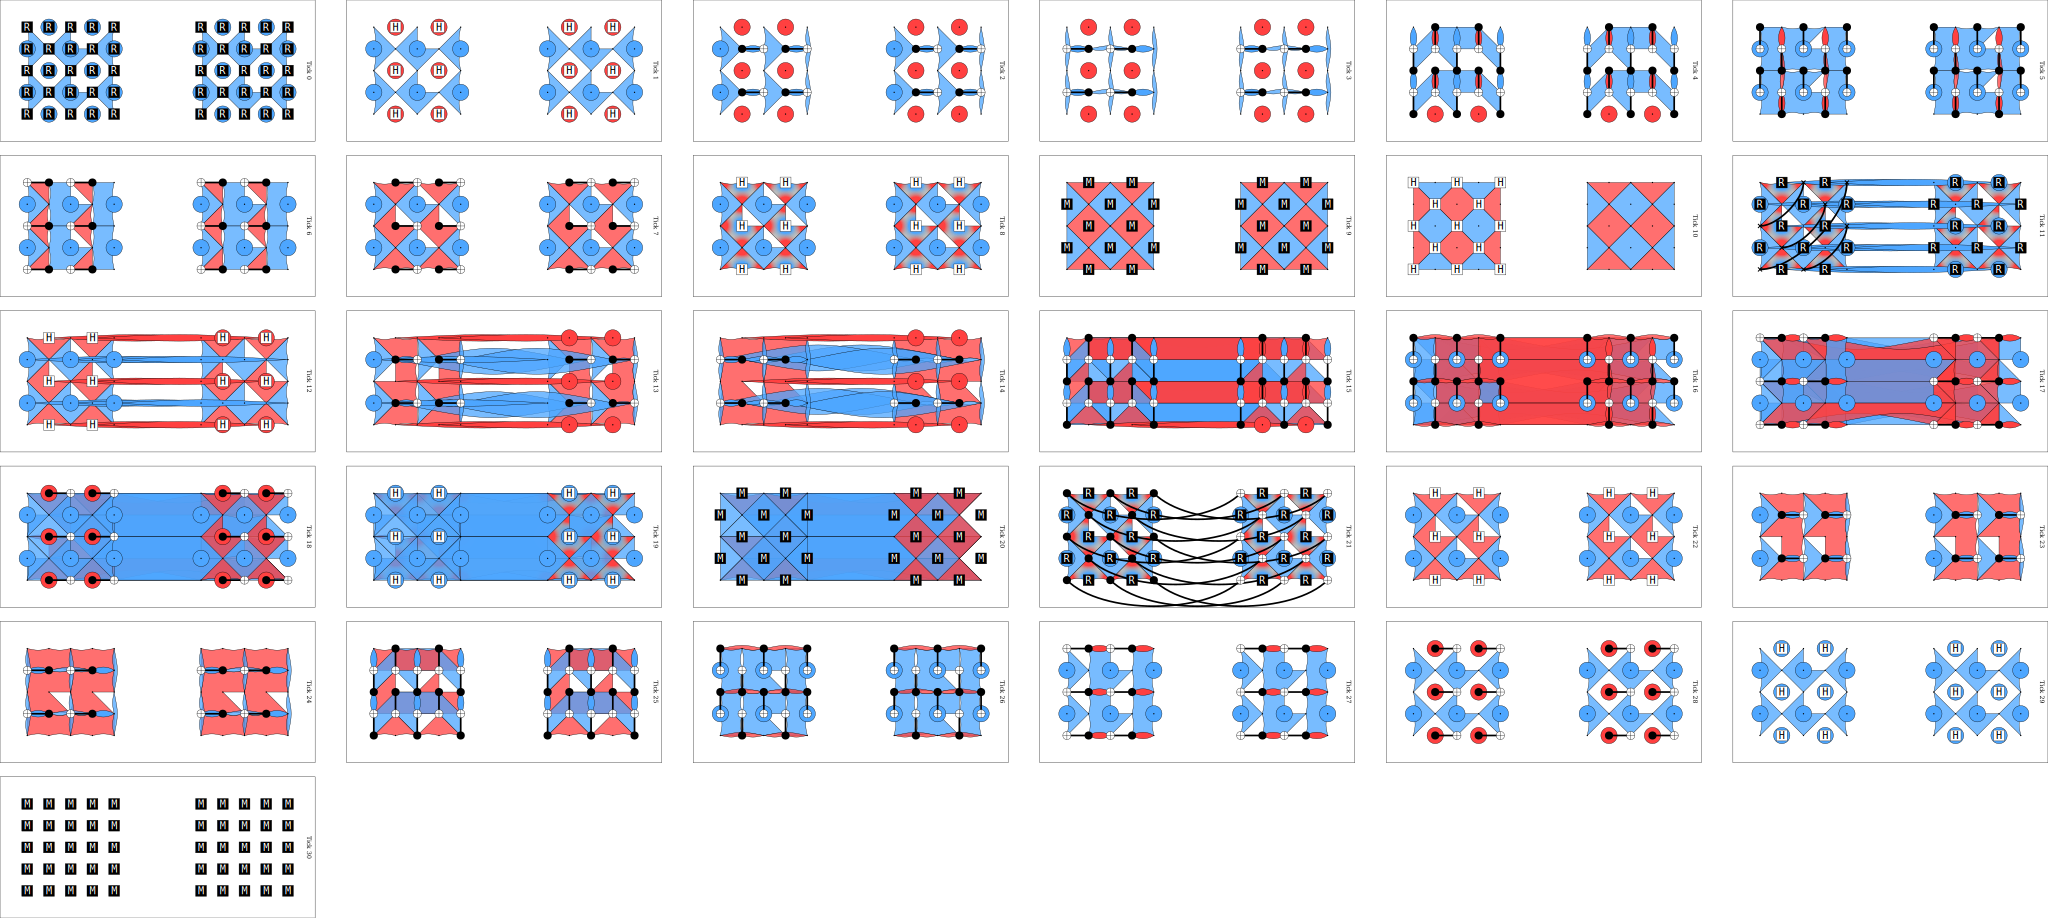

In [6]:
circ_d3, _, _ = build_bell_circuit(distance=3, rounds=1)
print(f"d=3 Bell circuit: {circ_d3.num_qubits} qubits, "
      f"{circ_d3.num_observables} observables, "
      f"{len(circ_d3.get_detector_coordinates())} detectors")
circ_d3.diagram('detslice-with-ops-svg')